# en este notebook pondre la variable dummy avenida_cerrada donde 1 si alguna avenida durante ese tiempo, 0 si no. la informacion se tomó de noticias

In [1]:
import pandas as pd

df = pd.read_excel('../datos/datos_imputados/CENTRO_IMPUTADO.xlsx')

In [2]:
df.columns

Index(['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF',
       'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDV'],
      dtype='object')

In [ ]:
df_dia.reset_index(inplace=True)

In [ ]:


cierres = [
    # Av. Constitución exprés (sondeos)
    {"inicio": "2023-04-11", "fin": "2023-07-11"},  # asumimos +2 meses
    
    # Puente Pedro Martínez (1er cierre total)
    {"inicio": "2024-02-14", "fin": "2025-01-19"},
    
    # Puente Pedro Martínez (nuevo cierre)
    {"inicio": "2025-08-01", "fin": "2025-10-01"},  # asumimos +2 meses
    
    # Av. San Jerónimo
    {"inicio": "2024-01-02", "fin": "2025-08-15"},
    
    # Av. Constitución exprés (Colón ↔ Pabellón M)
    {"inicio": "2025-07-07", "fin": "2025-08-31"},
]

df_dia['avenida_cerrada'] = 0

for c in cierres:
    inicio = pd.to_datetime(c["inicio"])
    fin = pd.to_datetime(c["fin"])
    df_dia.loc[(df_dia['date'] >= inicio) & (df_dia['date'] <= fin), 'avenida_cerrada'] = 1


In [ ]:
df_dia.avenida_cerrada.value_counts()

avenida_cerrada
0    1004
1     638
Name: count, dtype: int64

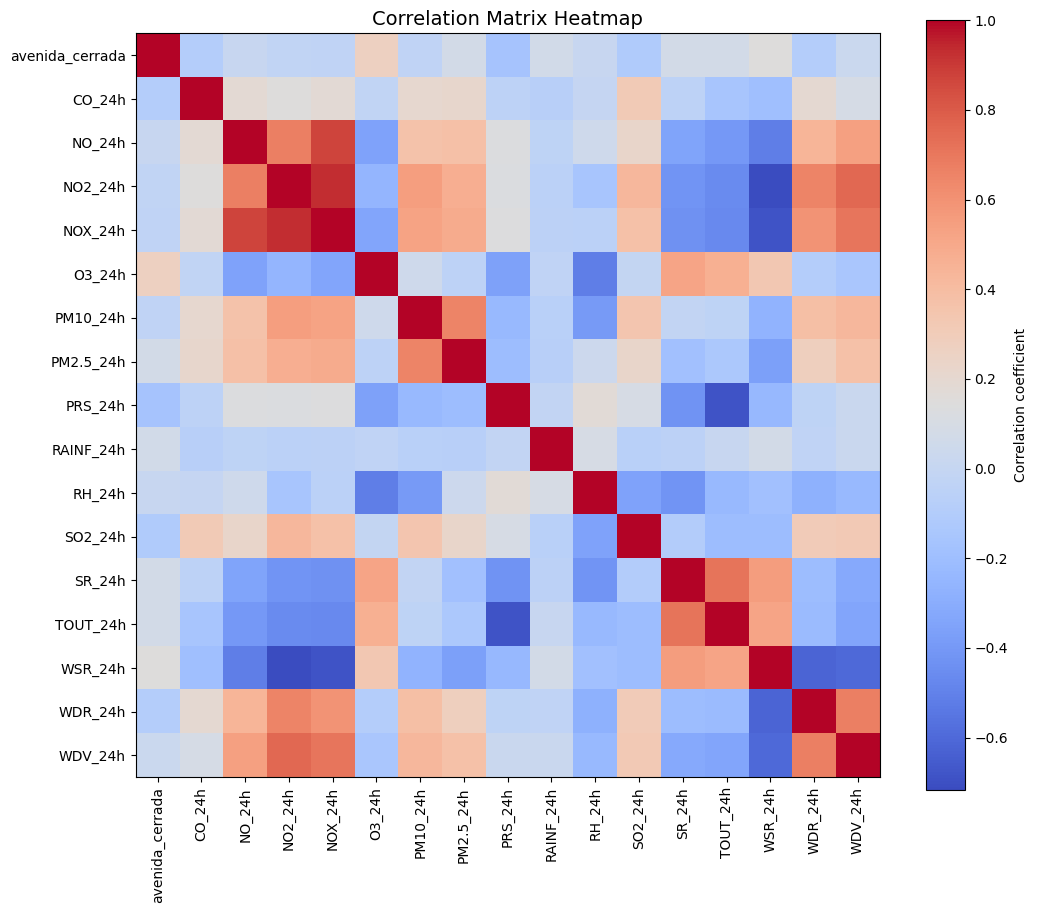

In [ ]:
import matplotlib.pyplot as plt
corr_matrix = df_dia[['avenida_cerrada',
       'CO_24h', 'NO_24h', 'NO2_24h', 'NOX_24h', 'O3_24h', 'PM10_24h',
       'PM2.5_24h', 'PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h']].corr()

plt.figure(figsize=(12,10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

In [ ]:
df_dia.columns

Index(['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF',
       'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDV', 'avenida_cerrada',
       'CO_24h', 'NO_24h', 'NO2_24h', 'NOX_24h', 'O3_24h', 'PM10_24h',
       'PM2.5_24h', 'PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h'],
      dtype='object')

In [ ]:
df_dia[['avenida_cerrada','CO_24h', 'NO_24h', 'NO2_24h', 'NOX_24h', 'O3_24h', 'PM10_24h',
       'PM2.5_24h', 'PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h']].corr()

,avenida_cerrada,CO_24h,NO_24h,NO2_24h,NOX_24h,O3_24h,PM10_24h,PM2.5_24h,PRS_24h,RAINF_24h,RH_24h,SO2_24h,SR_24h,TOUT_24h,WSR_24h,WDR_24h,WDV_24h
avenida_cerrada,1.000000,-0.091591,0.007783,-0.021788,-0.029888,0.264607,-0.026888,0.076032,-0.165099,0.070899,0.009093,-0.110413,0.080015,0.075957,0.145842,-0.090210,0.032152
CO_24h,-0.091591,1.000000,0.185322,0.145698,0.175960,-0.026573,0.205781,0.218113,-0.046516,-0.067394,-0.005573,0.313994,-0.040439,-0.152966,-0.191448,0.190194,0.091380
NO_24h,0.007783,0.185322,1.000000,0.671307,0.870752,-0.349115,0.364779,0.380225,0.129514,-0.039669,0.049604,0.222980,-0.344428,-0.399953,-0.515773,0.437185,0.538945
NO2_24h,-0.021788,0.145698,0.671307,1.000000,0.932776,-0.248400,0.545035,0.473660,0.127569,-0.055317,-0.149819,0.423362,-0.421617,-0.457828,-0.717695,0.652395,0.751824
NOX_24h,-0.029888,0.175960,0.870752,0.932776,1.000000,-0.340499,0.524934,0.485626,0.138708,-0.051078,-0.057491,0.373364,-0.430768,-0.466688,-0.685970,0.596385,0.709782
O3_24h,0.264607,-0.026573,-0.349115,-0.248400,-0.340499,1.000000,0.053265,-0.045182,-0.362054,-0.032967,-0.511384,-0.008476,0.521001,0.464638,0.329164,-0.090350,-0.145983
PM10_24h,-0.026888,0.205781,0.364779,0.545035,0.524934,0.053265,1.000000,0.652567,-0.232267,-0.062952,-0.392510,0.348625,-0.014968,-0.037420,-0.265324,0.386311,0.427401
PM2.5_24h,0.076032,0.218113,0.380225,0.473660,0.485626,-0.045182,0.652567,1.000000,-0.203203,-0.068932,0.037877,0.222497,-0.183103,-0.132295,-0.364562,0.277685,0.372565
PRS_24h,-0.165099,-0.046516,0.129514,0.127569,0.138708,-0.362054,-0.232267,-0.203203,1.000000,-0.018422,0.171377,0.100647,-0.427289,-0.685654,-0.236149,-0.035170,0.021642
RAINF_24h,0.070899,-0.067394,-0.039669,-0.055317,-0.051078,-0.032967,-0.062952,-0.068932,-0.018422,1.000000,0.095475,-0.066020,-0.053277,0.007765,0.078472,-0.029030,0.020889


In [ ]:
df_dia.to_excel('../datos/datos_dia_avenidas/CENTRO_AVENIDAS.xlsx', index=False)

In [ ]:
df_dia

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,...,TOUT_24h,WSR_24h,WDR_24h,WDV_24h,Calidad_PM10_24h,Calidad_PM2.5_24h,Calidad_O3_24h,Calidad_CO_24h,Calidad_SO2_24h,Calidad_NO2_24h
0,2021-01-01,4.675417,10.395833,20.309167,30.540833,23.000000,47.291667,31.737917,712.492500,0.0,...,7.267123,4.829035,137.800132,145.983095,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1,2021-01-02,4.686250,9.810000,18.176667,27.085000,27.725000,41.916667,22.372417,716.191667,0.0,...,9.748108,4.025347,126.085069,116.859722,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
2,2021-01-03,4.917500,18.946667,24.049167,41.128333,27.508333,70.625000,41.418417,713.975000,0.0,...,12.859340,3.352083,160.989583,148.380208,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
3,2021-01-04,5.011250,12.264167,22.066667,31.747500,28.100000,65.666667,22.968750,713.204167,0.0,...,16.398976,3.299132,201.380208,125.755208,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
4,2021-01-05,4.950833,12.531667,19.925000,29.960000,27.708333,53.833333,20.345000,712.741667,0.0,...,18.362135,3.580035,186.590278,122.693056,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,2025-06-26,1.240000,10.775000,6.450000,9.891667,30.500000,29.000000,12.368750,711.558333,0.0,...,27.385625,11.893403,67.734375,91.739931,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1638,2025-06-27,1.285833,3.189167,5.775000,8.862500,27.125000,26.791667,13.066667,711.604167,0.0,...,26.712830,10.600521,64.918403,87.198611,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1639,2025-06-28,1.232500,3.069167,3.900000,6.666667,26.458333,24.833333,11.525833,711.995833,0.0,...,26.505122,9.081250,71.036458,77.116667,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1640,2025-06-29,1.207083,2.336667,2.675000,4.866667,22.333333,22.958333,8.434583,711.216667,0.0,...,27.165104,10.761111,76.210069,80.399306,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación


In [ ]:
import pandas as pd

umbral_fases = {
    'PM10': [(76, 'Desactivación'), (156, 'Preventiva'), (277, 'Alerta'), (236, 'Contingencia Fase 1'), (277, 'Contingencia Fase 2')],
    'PM2.5': [(100, 'Desactivación'), (135, 'Preventiva'), (214, 'Alerta'), (214, 'Contingencia Fase 1'), (300, 'Contingencia Fase 2')],
    'O3': [(0.107, 'Desactivación'), (0.130, 'Preventiva'), (0.184, 'Alerta'), (0.154, 'Contingencia Fase 1'), (0.184, 'Contingencia Fase 2')],
    'CO': [(11.1, 'Desactivación'), (13.31, 'Preventiva'), (18.61, 'Alerta'), (15.51, 'Contingencia Fase 1'), (18.9, 'Contingencia Fase 2')],
    'SO2': [(12, 'Desactivación'), (13.9, 'Preventiva'), (15.9, 'Alerta'), (15.9, 'Contingencia Fase 1'), (18.9, 'Contingencia Fase 2')],
    'NO2': [(0.111, 'Desactivación'), (0.166, 'Preventiva'), (0.301, 'Alerta'), (0.221, 'Contingencia Fase 1'), (0.271, 'Contingencia Fase 2')],
}

def clasificar_fase(valor, contaminante):
    for umbral, fase in umbral_fases[contaminante]:
        if valor >= umbral:
            return fase
    return 'Desactivación'  # Si no cumple ningún umbral, se asigna Desactivación

# Función para calcular la calidad del aire para un DataFrame
def calcular_calidad_aire_df(df):
    for contaminante in umbral_fases.keys():
        df[f'Calidad_{contaminante}'] = df[contaminante].apply(lambda x: clasificar_fase(x, contaminante))
    return df



# Calcular la calidad del aire
df_resultado = calcular_calidad_aire_df(df_dia)

df_resultado.head()

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,...,Calidad_O3_24h,Calidad_CO_24h,Calidad_SO2_24h,Calidad_NO2_24h,Calidad_PM10,Calidad_PM2.5,Calidad_O3,Calidad_CO,Calidad_SO2,Calidad_NO2
0,2021-01-01,4.675417,10.395833,20.309167,30.540833,23.000000,47.291667,31.737917,712.492500,0.0,...,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1,2021-01-02,4.686250,9.810000,18.176667,27.085000,27.725000,41.916667,22.372417,716.191667,0.0,...,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
2,2021-01-03,4.917500,18.946667,24.049167,41.128333,27.508333,70.625000,41.418417,713.975000,0.0,...,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
3,2021-01-04,5.011250,12.264167,22.066667,31.747500,28.100000,65.666667,22.968750,713.204167,0.0,...,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
4,2021-01-05,4.950833,12.531667,19.925000,29.960000,27.708333,53.833333,20.345000,712.741667,0.0,...,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación


In [ ]:
value_counts = {}
for contaminante in df_resultado.columns:
    if contaminante.startswith('Calidad'):
        value_counts[contaminante] = df_resultado[contaminante].value_counts()

# Mostrar los resultados
for contaminante, counts in value_counts.items():
    print(f"{contaminante} - Value Counts:")
    print(counts)
    print()

Calidad_PM10_24h - Value Counts:
Calidad_PM10_24h
Desactivación    1642
Name: count, dtype: int64

Calidad_PM2.5_24h - Value Counts:
Calidad_PM2.5_24h
Desactivación    1642
Name: count, dtype: int64

Calidad_O3_24h - Value Counts:
Calidad_O3_24h
Desactivación    1642
Name: count, dtype: int64

Calidad_CO_24h - Value Counts:
Calidad_CO_24h
Desactivación    1642
Name: count, dtype: int64

Calidad_SO2_24h - Value Counts:
Calidad_SO2_24h
Desactivación    1642
Name: count, dtype: int64

Calidad_NO2_24h - Value Counts:
Calidad_NO2_24h
Desactivación    1642
Name: count, dtype: int64

Calidad_PM10 - Value Counts:
Calidad_PM10
Desactivación    1642
Name: count, dtype: int64

Calidad_PM2.5 - Value Counts:
Calidad_PM2.5
Desactivación    1642
Name: count, dtype: int64

Calidad_O3 - Value Counts:
Calidad_O3
Desactivación    1642
Name: count, dtype: int64

Calidad_CO - Value Counts:
Calidad_CO
Desactivación    1642
Name: count, dtype: int64

Calidad_SO2 - Value Counts:
Calidad_SO2
Desactivación    1

In [ ]:
datita = pd.read_excel('../datos/datos_dia_avenidas/CENTRO_AVENIDAS.xlsx')

In [ ]:
datita.columns

Index(['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF',
       'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDV', 'avenida_cerrada',
       'CO_24h', 'NO_24h', 'NO2_24h', 'NOX_24h', 'O3_24h', 'PM10_24h',
       'PM2.5_24h', 'PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h'],
      dtype='object')

In [ ]:
data = datita.drop(columns=['PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h','O3_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF',
       'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDV', 'avenida_cerrada'])


In [ ]:
data.columns = [col.replace('_24h', '') for col in data.columns]


In [ ]:
df = data
df

,date,CO,NO,NO2,NOX,PM10,PM2.5
0,2021-01-01,4.759517,13.779244,21.793775,35.498159,55.803517,43.106937
1,2021-01-02,4.641181,9.113819,17.936736,26.374861,39.743056,22.088799
2,2021-01-03,4.818750,15.440903,22.788576,37.750660,62.619792,35.742743
3,2021-01-04,4.925764,14.499097,22.297014,34.068160,64.576389,30.524396
4,2021-01-05,5.006337,11.945347,21.094583,30.255312,59.173611,21.093750
...,...,...,...,...,...,...,...
1637,2025-06-26,1.231719,19.377257,6.093924,9.612326,29.519097,12.961128
1638,2025-06-27,1.250608,4.870868,5.662674,8.859201,26.857639,11.821337
1639,2025-06-28,1.267778,2.967222,4.861632,7.784375,25.868056,12.209479
1640,2025-06-29,1.211337,2.818681,3.051563,5.462326,24.118056,10.426892


In [ ]:
df.to_csv('/Users/marielalvarez/Downloads/CENTRO_MODELO.csv', index=True)